In [ ]:
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_prep import find_duplicates, remove_duplicates
from src.visualization import plot_categorical_distribution, plot_numeric_distribution, plot_correlation_heatmap

# Diabetes prediction - EDA

In [2]:
data = pd.read_csv("../data/processed/diabetes_prediction_dataset.csv")

In [3]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


Let's begin by checking the data for missing values.

In [4]:
print(data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


There seems ti be no missing values. However, this is not completely true. We'll see later when we get to exploring the `smoking_history` attribute.

Let's now check for duplicates. With 100,000 records but only nine features, some of which are low-cardinality (e.g. rounded age, bmi, or glucose values), duplicate rows are likely to occur simply by chance. If a duplicate row ends up split across the train and test sets, the model would effectively be evaluated on data it has already seen during training - a form of data leakage that inflates performance metrics.

In [5]:
duplicate_rows, summary, group_cols = find_duplicates(data)
group_sizes = duplicate_rows.groupby(group_cols).size()

print(group_sizes.value_counts().sort_index())

Rows involved in duplication: 6939
Duplicate rows to remove: 3854 (3.85%)
Unique duplicate groups: 3085
2    2523
3     431
4      85
5      29
6       9
7       5
8       1
9       2
Name: count, dtype: int64


In [6]:
data = remove_duplicates(data)

Rows before: 100000
Rows after: 96146
Removed: 3854


We also check for duplicates while excluding the `diabetes` column. This identifies rows that share the exact same feature values but have a different target label - a case that a plain duplicate check (including the target) would miss entirely, since the rows themselves are not fully identical.

In [7]:
subset_cols = [c for c in data.columns if c != "diabetes"]
duplicate_rows, summary, group_cols = find_duplicates(data, subset=subset_cols)

Rows involved in duplication: 182
Duplicate rows to remove: 91 (0.09%)
Unique duplicate groups: 91


We found 91 groups of rows (182 rows total, ~0.09% of the dataset) that share identical feature values but disagree on the `diabetes` label. Unlike the full duplicates removed earlier, these are not treated as redundant data and are kept in the dataset.

This overlap is expected: several of the underlying features (e.g. rounded age, bmi, and glucose values) are low-cardinality, so distinct individuals can plausibly share the same recorded values while genuinely differing in diagnosis. Removing or arbitrarily relabeling these rows would not resolve the underlying ambiguity - it would only hide it. This is noted here as a limitation of the dataset's feature resolution.

Now, let's take a look at the `gender` and `smoking_history` columns.

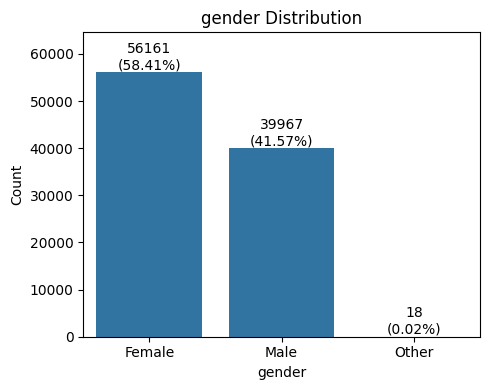

In [8]:
plot_categorical_distribution(data, "gender")

The dataset contains three categories: `female` (56,161), `male` (39,967), and `other` (18). The `other` category represents only 0.02% of the data - far too few observations to support any statistically meaningful analysis or for a model to learn a reliable pattern from. Keeping it would effectively be noise rather than signal, and one-hot encoding it would add a column that is almost entirely zeros. For these reasons, the 18 `other` rows are dropped from the dataset.

The remaining two categories are also not evenly distributed: females make up about 58% of the dataset and males about 42%. This imbalance is worth keeping in mind during modeling, though it is far less severe than the target variable's imbalance and does not require a separate correction on its own - it is simply noted here as part of understanding the data.

In [9]:
data = data[data.gender != "Other"].reset_index(drop=True)

In [10]:
print(data.gender.unique())

['Female' 'Male']


Since `smoking_history` has many questionable values we need to take a look at it.

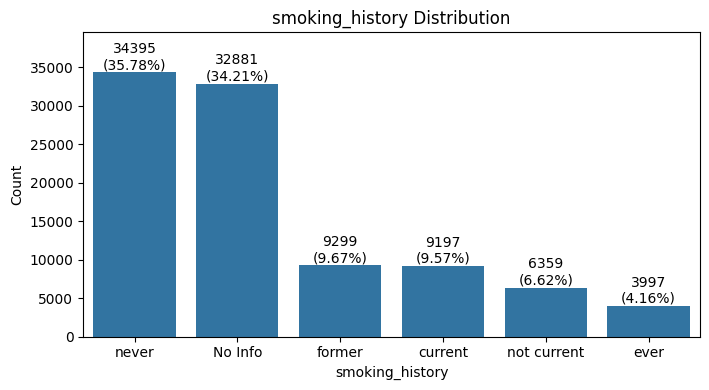

In [11]:
plot_categorical_distribution(data, "smoking_history")

The `smoking_history` categories are not mutually exclusive in a fully intuitive way. According to the dataset creator, `former` and `not current` both represent past smokers, differing only in how recently they quit, while `ever` broadly overlaps with both `current` and `former` (anyone who has smoked at any point in their life). This ambiguity has also been noted by other users of the dataset and is treated here as a known limitation of the feature's granularity. The high proportion of `No Info` values (~34% of the dataset) observed here has also been independently reported by other users of the dataset, confirming this is a known and consistent characteristic of the data rather than an artifact specific to this analysis.

Given the overlap between `former`, `not current`, and `ever` described above, these three categories are consolidated into a single `past_smoker` category. This reduces noise introduced by an ambiguous boundary between categories that the dataset's documentation itself does not clearly distinguish, while keeping `never`, `current`, and `No Info` as separate, unambiguous categories.

In [12]:
smoking_map = {
    "never": "never",
    "No Info": "No Info",
    "current": "current",
    "former": "past_smoker",
    "not current": "past_smoker",
    "ever": "past_smoker"
}

data.smoking_history = data.smoking_history.map(smoking_map)

print(data.smoking_history.value_counts())

smoking_history
never          34395
No Info        32881
past_smoker    19655
current         9197
Name: count, dtype: int64


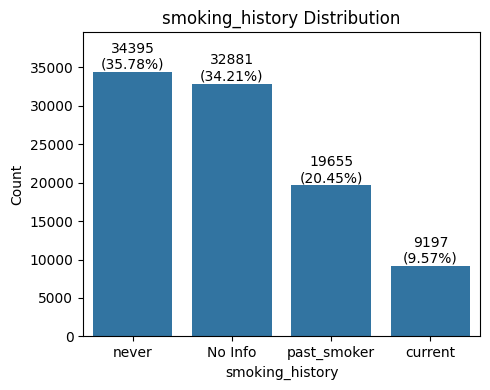

In [13]:
plot_categorical_distribution(data, "smoking_history")

Let's proceed with `age`, `bmi`, `blood_glucose_level` and `HbA1c_level`

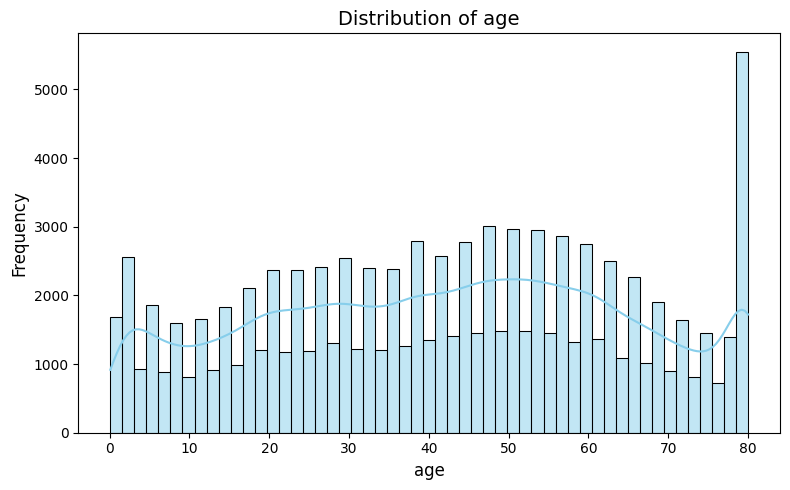

Statistical Measures for age:
count    96128.000000
mean        41.796617
std         22.463329
min          0.080000
25%         24.000000
50%         43.000000
75%         59.000000
max         80.000000
Name: age, dtype: float64


In [14]:
plot_numeric_distribution(data, "age")

The `age` column ranges from 0.08 to 80 years (mean ≈ 41.8, median = 43). The minimum value of 0.08 (approximately one month old) is unusual for a diabetes risk dataset, since type 2 diabetes in infants is exceptionally rare - this may reflect synthetic data generation rather than a realistic clinical population. The maximum is capped at exactly 80, visible as a spike in the histogram, suggesting the source data top-codes all ages of 80 and above into a single value rather than recording true age beyond that point. Both observations are noted here as limitations of the dataset's realism, consistent with the earlier findings for `bmi`, `HbA1c_level`, and `blood_glucose_level`.

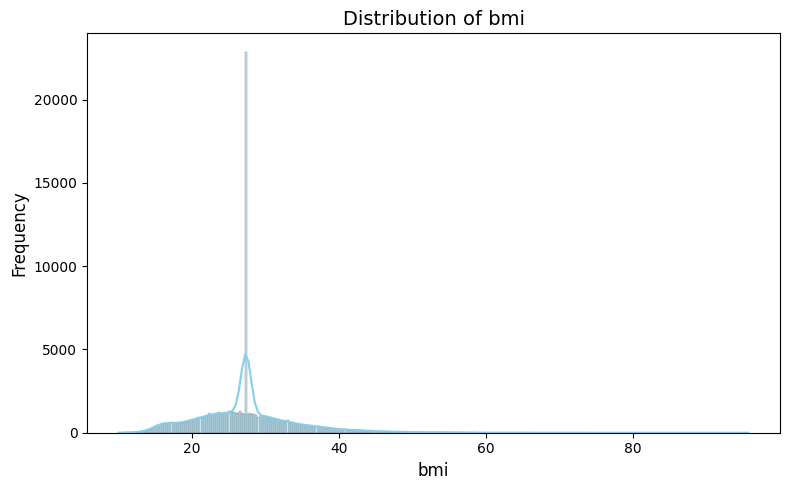

Statistical Measures for bmi:
count    96128.000000
mean        27.321450
std          6.767811
min         10.010000
25%         23.400000
50%         27.320000
75%         29.860000
max         95.690000
Name: bmi, dtype: float64


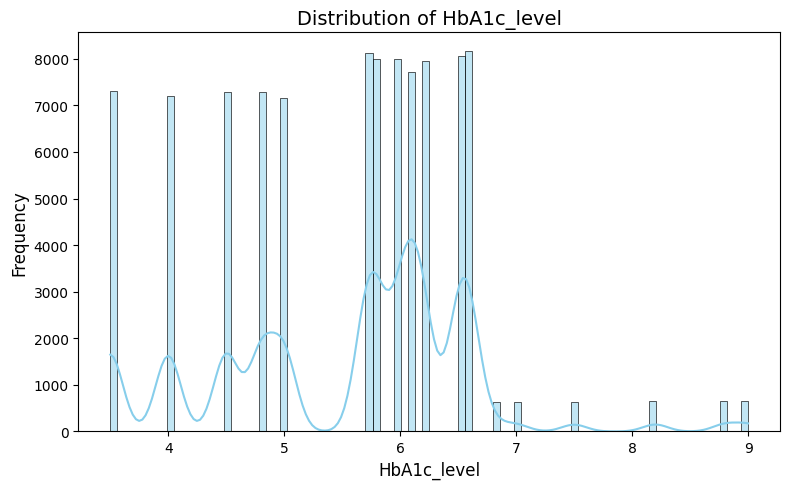

Statistical Measures for HbA1c_level:
count    96128.000000
mean         5.532633
std          1.073225
min          3.500000
25%          4.800000
50%          5.800000
75%          6.200000
max          9.000000
Name: HbA1c_level, dtype: float64


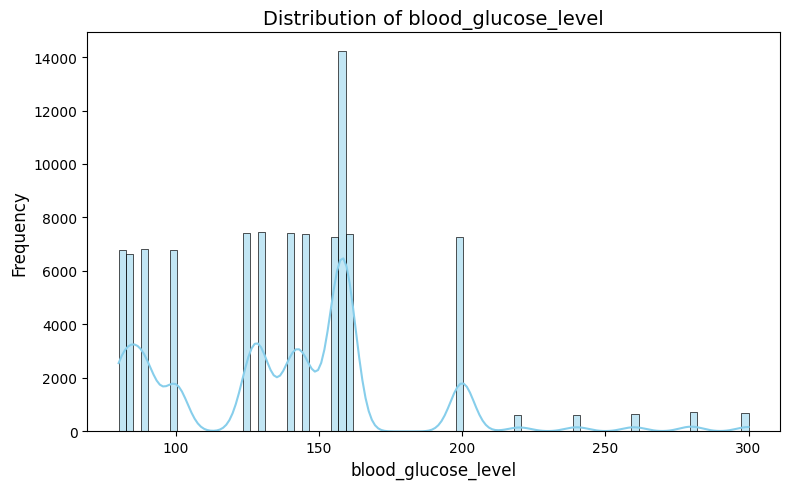

Statistical Measures for blood_glucose_level:
count    96128.000000
mean       138.218001
std         40.911190
min         80.000000
25%        100.000000
50%        140.000000
75%        159.000000
max        300.000000
Name: blood_glucose_level, dtype: float64


In [15]:
plot_numeric_distribution(data, "bmi")
plot_numeric_distribution(data, "HbA1c_level")
plot_numeric_distribution(data, "blood_glucose_level")

In [16]:
print(data.bmi.value_counts().head(10))
print(data.HbA1c_level.value_counts().head(10))
print(data.blood_glucose_level.value_counts().head(10))

bmi
27.32    21659
23.00      103
27.12      101
24.96      100
27.80      100
22.40       99
25.00       99
25.60       98
24.50       94
26.70       94
Name: count, dtype: int64
HbA1c_level
6.6    8161
5.7    8123
6.5    8051
5.8    7992
6.0    7987
6.2    7956
6.1    7712
3.5    7316
4.8    7296
4.5    7289
Name: count, dtype: int64
blood_glucose_level
159    7475
130    7471
126    7419
140    7414
160    7393
145    7371
200    7289
155    7285
90     6820
80     6785
Name: count, dtype: int64


In [17]:
print(f"Unique HbA1c values: {data.HbA1c_level.nunique()}")
print(f"Unique glucose values: {data.blood_glucose_level.nunique()}")

Unique HbA1c values: 18
Unique glucose values: 18


**Data quality observation - bmi, HbA1c_level, blood_glucose_level**

The `bmi` distribution shows an unusually sharp concentration around a single value: `27.32` appears 21,659 times, accounting for roughly 22.5% of the entire dataset, while every other value appears at most ~100 times. This strongly suggests that a large portion of `bmi` entries were imputed with a single placeholder (likely a population mean or default value) rather than independently measured - a known characteristic of this dataset rather than an artifact of this analysis.

Similarly, `HbA1c_level` and `blood_glucose_level` each take on only 18 unique values across the entire dataset, despite both being continuous physiological measurements in reality. This confirms the earlier visual observation of discrete spikes in their histograms: the underlying data was likely quantized, bucketed, or synthetically generated rather than collected as raw individual lab measurements. This is noted here as a limitation affecting the realism of the dataset, and is relevant context when interpreting the strength of their correlation with the target variable discussed earlier.

Let's plot the heart `disease` and `hypertension` columns

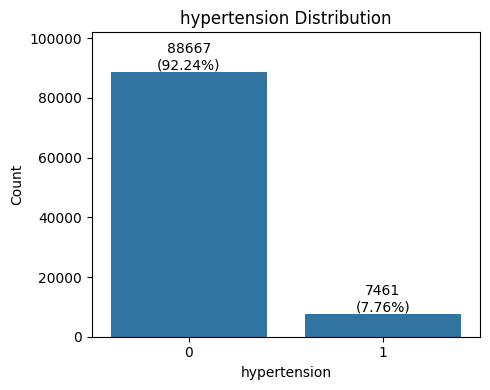

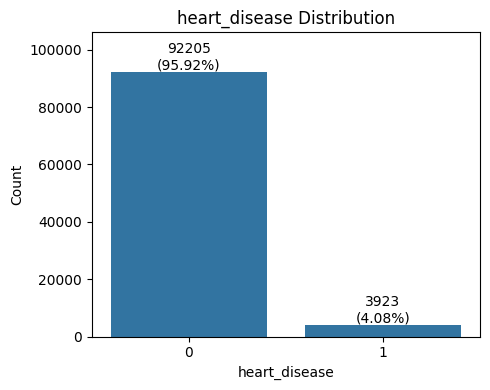

In [18]:
plot_categorical_distribution(data, "hypertension")
plot_categorical_distribution(data, "heart_disease")

Both `hypertension` and `heart_disease` are highly imbalanced binary features: only 7.76% of respondents report hypertension, and 4.08% report heart disease. These proportions are broadly consistent with real-world population prevalence rates for these conditions, so the imbalance itself is not a data quality concern - unlike `bmi`, `HbA1c_level`, and `blood_glucose_level` discussed above, these values appear plausible rather than synthetic.

Given the outliers observed in `bmi` and the discretized nature of `HbA1c_level` and `blood_glucose_level`, Spearman correlation is used here instead of Pearson. Spearman measures monotonic rather than strictly linear relationships and is more robust to outliers, making it a more appropriate choice given the data quality limitations discussed earlier.

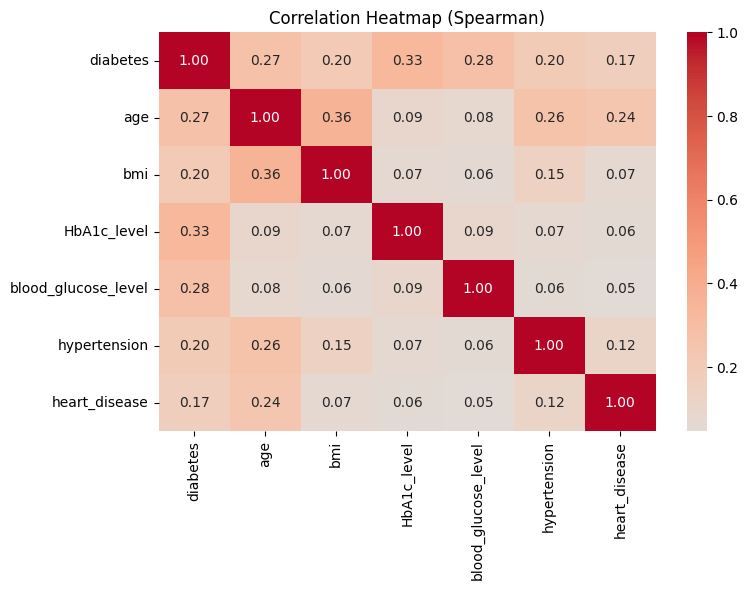

In [19]:
plot_correlation_heatmap(data, ["diabetes", "age", "bmi", "HbA1c_level", "blood_glucose_level", "hypertension", "heart_disease"], title="Correlation Heatmap (Spearman)")

**Interpretation**

`HbA1c_level` (0.33) and `blood_glucose_level` (0.28) are the two features most strongly correlated with `diabetes`, consistent with them being the clinical diagnostic criteria for the condition rather than independent risk factors, as discussed earlier.

`age` (0.27) shows a moderate correlation with diabetes, in line with type 2 diabetes being more common in older adults. `hypertension` (0.20) and `heart_disease` (0.17) show weaker but non-trivial correlations, consistent with their role as comorbidities rather than direct diagnostic criteria. `bmi` shows the weakest correlation with diabetes among the numeric features (0.20), somewhat lower than might be clinically expected - likely related to the data quality concerns raised earlier regarding the large proportion of placeholder-like `bmi` values.

Among the features themselves, `age` and `bmi` show the strongest inter-feature correlation (0.36), while `hypertension` and `heart_disease` are also moderately correlated with `age` (0.26 and 0.24), reflecting the expected co-occurrence of these conditions with older age rather than any redundancy that would require removing a feature at this stage.